# Manual Linear SVM for MNIST (7 vs Not-7)

This notebook implements Phase 1 of the SVM-only MNIST project: a binary classifier that predicts whether an image is digit **7** or **not 7**.

- TensorFlow is used only to load the MNIST dataset.
- The **linear SVM model is manual** and trained with NumPy.
- Preprocessing, feature extraction, splitting, and evaluation use helper libraries.
- The same manual SVM is evaluated on three feature pipelines: flattened pixels, PCA features, and HOG features.
- The diagnostics focus on imbalance, threshold choice, and practical error analysis because the positive class is much smaller than the negative class.

Before running the notebook, install the required packages if needed:

`pip install tensorflow numpy pandas scikit-learn scikit-image notebook`


## Problem Definition

Let $x$ be an MNIST image and let $\phi(x)$ be the selected feature representation.

- Input: $\phi(x) \in \mathbb{R}^d$
- Output label: $y \in \{+1, -1\}$ where `+1` means digit `7` and `-1` means `not 7`
- Decision rule: $\hat{y} = \text{sign}(w^T \phi(x) + b)$

The notebook keeps the original $28 \times 28$ image size, normalizes pixel values to $[0, 1]$, creates binary labels, and evaluates the manual SVM on train, validation, and test splits.


## Loss Function and Optimization

The manual model minimizes weighted hinge loss with L2 regularization:

$$J(w, b) = \frac{1}{2} \|w\|^2 + C \frac{1}{N} \sum_{i=1}^{N} \text{class\_weight}_i \max(0, 1 - y_i (w^T x_i + b))$$

- `C` controls the regularization-versus-margin tradeoff.
- Inverse-frequency class weights reduce the impact of the `7` versus `not 7` imbalance.
- Optimization uses manual mini-batch subgradient descent with learning-rate decay.


In [10]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import tensorflow as tf
from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from skimage.feature import hog  # pyright: ignore[reportMissingModuleSource]

SEED = 42
np.random.seed(SEED)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)
plt.style.use("seaborn-v0_8-whitegrid")


def find_project_root():
    current = Path.cwd().resolve()
    for candidate in [current, *current.parents]:
        if (candidate / "README.md").exists() and (candidate / "Binary Classification").exists():
            return candidate
    return current


PROJECT_ROOT = find_project_root()
OUTPUT_DIR = PROJECT_ROOT / "Binary Classification" / "LinearSVM" / "outputs"
FIGURE_DIR = OUTPUT_DIR / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)


In [11]:
def load_mnist_binary():
    (x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()
    x_train = x_train.astype(np.float32) / 255.0
    x_test = x_test.astype(np.float32) / 255.0
    y_train = np.where(y_train == 7, 1, -1).astype(np.int8)
    y_test = np.where(y_test == 7, 1, -1).astype(np.int8)
    return {
        "x_train": x_train,
        "y_train": y_train,
        "x_test": x_test,
        "y_test": y_test,
    }


def stratified_train_val_split(X, y, val_ratio=0.2, random_state=42):
    x_train, x_val, y_train, y_val = train_test_split(
        X,
        y,
        test_size=val_ratio,
        random_state=random_state,
        stratify=y,
    )
    return {
        "x_train": x_train,
        "y_train": y_train,
        "x_val": x_val,
        "y_val": y_val,
    }


def summarize_split(name, y):
    return {
        "split": name,
        "samples": int(len(y)),
        "digit_7": int(np.sum(y == 1)),
        "not_7": int(np.sum(y == -1)),
    }


## Feature Pipelines

The same manual SVM is trained three times with different input features:

1. **Flattened pixels**: direct `28 x 28 -> 784` vector.
2. **PCA features**: dimensionality reduction with `sklearn.decomposition.PCA` fit on training data only.
3. **HOG features**: gradient-based descriptors extracted with `skimage.feature.hog`.

Feature scaling is performed with `StandardScaler`, fit on the training split only and reused on validation and test data.


In [12]:
def flatten_features(X):
    return X.reshape(X.shape[0], -1).astype(np.float32)


def fit_pca(X_train, variance_threshold=0.95):
    pca = PCA(n_components=variance_threshold, svd_solver="full")
    pca.fit(flatten_features(X_train))
    return pca


def transform_pca(X, pca_state):
    return pca_state.transform(flatten_features(X)).astype(np.float32)


def hog_features(X, orientations=9, pixels_per_cell=(4, 4), cells_per_block=(2, 2)):
    descriptors = [
        hog(
            image,
            orientations=orientations,
            pixels_per_cell=pixels_per_cell,
            cells_per_block=cells_per_block,
            block_norm="L2-Hys",
            feature_vector=True,
        )
        for image in X
    ]
    return np.vstack(descriptors).astype(np.float32)


def prepare_feature_set(feature_mode, split_data):
    if feature_mode == "flatten":
        x_train = flatten_features(split_data["x_train"])
        x_val = flatten_features(split_data["x_val"])
        x_test = flatten_features(split_data["x_test"])
        metadata = {"feature_mode": feature_mode}
    elif feature_mode == "pca":
        pca_state = fit_pca(split_data["x_train"], variance_threshold=0.95)
        x_train = transform_pca(split_data["x_train"], pca_state)
        x_val = transform_pca(split_data["x_val"], pca_state)
        x_test = transform_pca(split_data["x_test"], pca_state)
        metadata = {
            "feature_mode": feature_mode,
            "pca_components": int(pca_state.n_components_),
            "explained_variance_ratio": float(np.sum(pca_state.explained_variance_ratio_)),
        }
    elif feature_mode == "hog":
        x_train = hog_features(split_data["x_train"])
        x_val = hog_features(split_data["x_val"])
        x_test = hog_features(split_data["x_test"])
        metadata = {
            "feature_mode": feature_mode,
            "orientations": 9,
            "pixels_per_cell": (4, 4),
            "cells_per_block": (2, 2),
        }
    else:
        raise ValueError(f"Unsupported feature_mode: {feature_mode}")

    scaler = StandardScaler()
    x_train = scaler.fit_transform(x_train).astype(np.float32)
    x_val = scaler.transform(x_val).astype(np.float32)
    x_test = scaler.transform(x_test).astype(np.float32)

    features = {
        "x_train": x_train,
        "x_val": x_val,
        "x_test": x_test,
    }
    metadata["feature_dimension"] = int(x_train.shape[1])
    feature_shapes = {
        split_name: tuple(values.shape)
        for split_name, values in features.items()
    }
    return features, metadata, feature_shapes


In [13]:
class LinearSVMManual:
    def __init__(self, C=1.0, epochs=20, batch_size=256, lr=0.01, lr_decay=0.95, random_state=42):
        self.C = C
        self.epochs = epochs
        self.batch_size = batch_size
        self.lr = lr
        self.lr_decay = lr_decay
        self.random_state = random_state
        self.w = None
        self.b = 0.0
        self.class_weight_ = None
        self.history = []

    def _weights_for_labels(self, y):
        import numpy as np
        return np.array([self.class_weight_.get(int(label), 1.0) for label in y], dtype=np.float32)

    def _objective(self, X, y, sample_weights):
        import numpy as np
        margins = y * (X @ self.w + self.b)
        hinge = np.maximum(0.0, 1.0 - margins)
        return float(0.5 * np.dot(self.w, self.w) + self.C * np.mean(sample_weights * hinge))

    def fit(self, X_train, y_train, X_val=None, y_val=None):
        import numpy as np
        X_train = np.asarray(X_train, dtype=np.float32)
        y_train = np.asarray(y_train, dtype=np.float32)

        num_samples, num_features = X_train.shape
        self.w = np.zeros(num_features, dtype=np.float32)
        self.b = 0.0
        self.class_weight_ = inverse_frequency_class_weights(y_train.astype(np.int8))
        sample_weights = self._weights_for_labels(y_train)
        rng = np.random.default_rng(self.random_state)
        current_lr = self.lr
        self.history = []

        m_w = np.zeros_like(self.w)
        v_w = np.zeros_like(self.w)
        m_b = 0.0
        v_b = 0.0
        beta1, beta2, epsilon = 0.9, 0.999, 1e-8
        t = 0
        
        best_val_loss = float('inf')
        patience = 5
        patience_counter = 0
        best_w = None
        best_b = None

        for epoch in range(self.epochs):
            indices = rng.permutation(num_samples)

            for start in range(0, num_samples, self.batch_size):
                batch_idx = indices[start:start + self.batch_size]
                X_batch = X_train[batch_idx]
                y_batch = y_train[batch_idx]
                batch_weights = sample_weights[batch_idx]

                margins = y_batch * (X_batch @ self.w + self.b)
                active = margins < 1.0
                grad_w = self.w.copy()
                grad_b = 0.0

                if np.any(active):
                    weighted_labels = batch_weights[active] * y_batch[active]
                    grad_w -= self.C * np.sum(weighted_labels[:, None] * X_batch[active], axis=0) / len(batch_idx)
                    grad_b -= self.C * np.sum(weighted_labels) / len(batch_idx)

                t += 1
                m_w = beta1 * m_w + (1 - beta1) * grad_w
                v_w = beta2 * v_w + (1 - beta2) * (grad_w ** 2)
                m_b = beta1 * m_b + (1 - beta1) * grad_b
                v_b = beta2 * v_b + (1 - beta2) * (grad_b ** 2)

                m_w_hat = m_w / (1 - beta1 ** t)
                v_w_hat = v_w / (1 - beta2 ** t)
                m_b_hat = m_b / (1 - beta1 ** t)
                v_b_hat = v_b / (1 - beta2 ** t)

                self.w -= current_lr * m_w_hat / (np.sqrt(v_w_hat) + epsilon)
                self.b -= current_lr * m_b_hat / (np.sqrt(v_b_hat) + epsilon)

            history_row = {
                "epoch": epoch + 1,
                "train_loss": self._objective(X_train, y_train, sample_weights),
            }

            if X_val is not None and y_val is not None:
                X_val = np.asarray(X_val, dtype=np.float32)
                y_val = np.asarray(y_val, dtype=np.float32)
                val_weights = self._weights_for_labels(y_val)
                val_pred = self.predict(X_val)
                val_report = classification_report_binary(y_val, val_pred)
                history_row["val_loss"] = self._objective(X_val, y_val, val_weights)
                history_row["val_accuracy"] = val_report["accuracy"]
                history_row["val_f1"] = val_report["f1"]
                
                if history_row["val_loss"] < best_val_loss:
                    best_val_loss = history_row["val_loss"]
                    best_w = self.w.copy()
                    best_b = self.b
                    patience_counter = 0
                else:
                    patience_counter += 1

            self.history.append(history_row)
            current_lr *= self.lr_decay
            
            if patience_counter >= patience:
                break

        if best_w is not None:
            self.w = best_w
            self.b = best_b

        return self

    def decision_function(self, X):
        import numpy as np
        X = np.asarray(X, dtype=np.float32)
        return X @ self.w + self.b

    def predict(self, X):
        import numpy as np
        scores = self.decision_function(X)
        return np.where(scores >= 0.0, 1, -1).astype(np.int8)

In [14]:
def run_experiment(feature_mode, split_data, model_kwargs=None):
    features, metadata, feature_shapes = prepare_feature_set(feature_mode, split_data)
    config = {
        "C": 1.0,
        "epochs": 20,
        "batch_size": 256,
        "lr": 0.01,
        "lr_decay": 0.95,
        "random_state": SEED,
    }
    if model_kwargs is not None:
        config.update(model_kwargs)

    model = LinearSVMManual(**config)
    model.fit(features["x_train"], split_data["y_train"], features["x_val"], split_data["y_val"])

    predictions = {}
    reports = {}
    for split_name in ("train", "val", "test"):
        x_key = f"x_{split_name}"
        y_key = f"y_{split_name}"
        predictions[split_name] = model.predict(features[x_key])
        reports[split_name] = classification_report_binary(split_data[y_key], predictions[split_name])

    return {
        "feature_mode": feature_mode,
        "feature_metadata": metadata,
        "feature_shapes": feature_shapes,
        "model_config": config,
        "model": model,
        "history": pd.DataFrame(model.history),
        "predictions": predictions,
        "reports": reports,
        "confusion_matrix": confusion_matrix(split_data["y_test"], predictions["test"], labels=[1, -1]),
    }


def build_results_table(results):
    rows = []
    for feature_mode, result in results.items():
        row = {
            "feature_mode": feature_mode,
            "feature_dimension": result["feature_metadata"]["feature_dimension"],
            "train_accuracy": result["reports"]["train"]["accuracy"],
            "val_accuracy": result["reports"]["val"]["accuracy"],
            "val_precision": result["reports"]["val"]["precision"],
            "val_recall": result["reports"]["val"]["recall"],
            "val_f1": result["reports"]["val"]["f1"],
            "test_accuracy": result["reports"]["test"]["accuracy"],
            "test_precision": result["reports"]["test"]["precision"],
            "test_recall": result["reports"]["test"]["recall"],
            "test_f1": result["reports"]["test"]["f1"],
        }
        rows.append(row)

    table = pd.DataFrame(rows)
    return table.sort_values(["val_f1", "test_f1"], ascending=False).reset_index(drop=True)


In [15]:
dataset = load_mnist_binary()
split_data = stratified_train_val_split(dataset["x_train"], dataset["y_train"], val_ratio=0.2, random_state=SEED)
split_data["x_test"] = dataset["x_test"]
split_data["y_test"] = dataset["y_test"]

split_summary = pd.DataFrame([
    summarize_split("train", split_data["y_train"]),
    summarize_split("validation", split_data["y_val"]),
    summarize_split("test", split_data["y_test"]),
])
split_summary


,split,samples,digit_7,not_7
0,train,48000,5012,42988
1,validation,12000,1253,10747
2,test,10000,1028,8972


In [16]:
feature_modes = ("flatten", "pca", "hog")
experiments = {feature_mode: run_experiment(feature_mode, split_data) for feature_mode in feature_modes}
comparison_table = build_results_table(experiments)
comparison_table


,feature_mode,feature_dimension,train_accuracy,val_accuracy,val_precision,val_recall,val_f1,test_accuracy,test_precision,test_recall,test_f1
0,hog,1296,0.982021,0.983333,0.869474,0.988827,0.925317,0.9830,0.870466,0.980545,0.922232
1,flatten,784,0.963917,0.965167,0.768835,0.952913,0.851033,0.9630,0.756630,0.943580,0.839827
2,pca,154,0.965083,0.965833,0.795375,0.905826,0.847015,0.9651,0.786498,0.906615,0.842296


## Visual Diagnostics

These plots are designed to answer four practical questions about the binary SVM:

1. How imbalanced is the digit-7 detection task?
2. Which feature pipeline gives the best validation and test F1?
3. How does the decision threshold trade precision against recall?
4. What kinds of images does the best SVM confuse most confidently?

The figures are also saved under `Binary Classification/SVM/outputs/figures` when the cell runs.


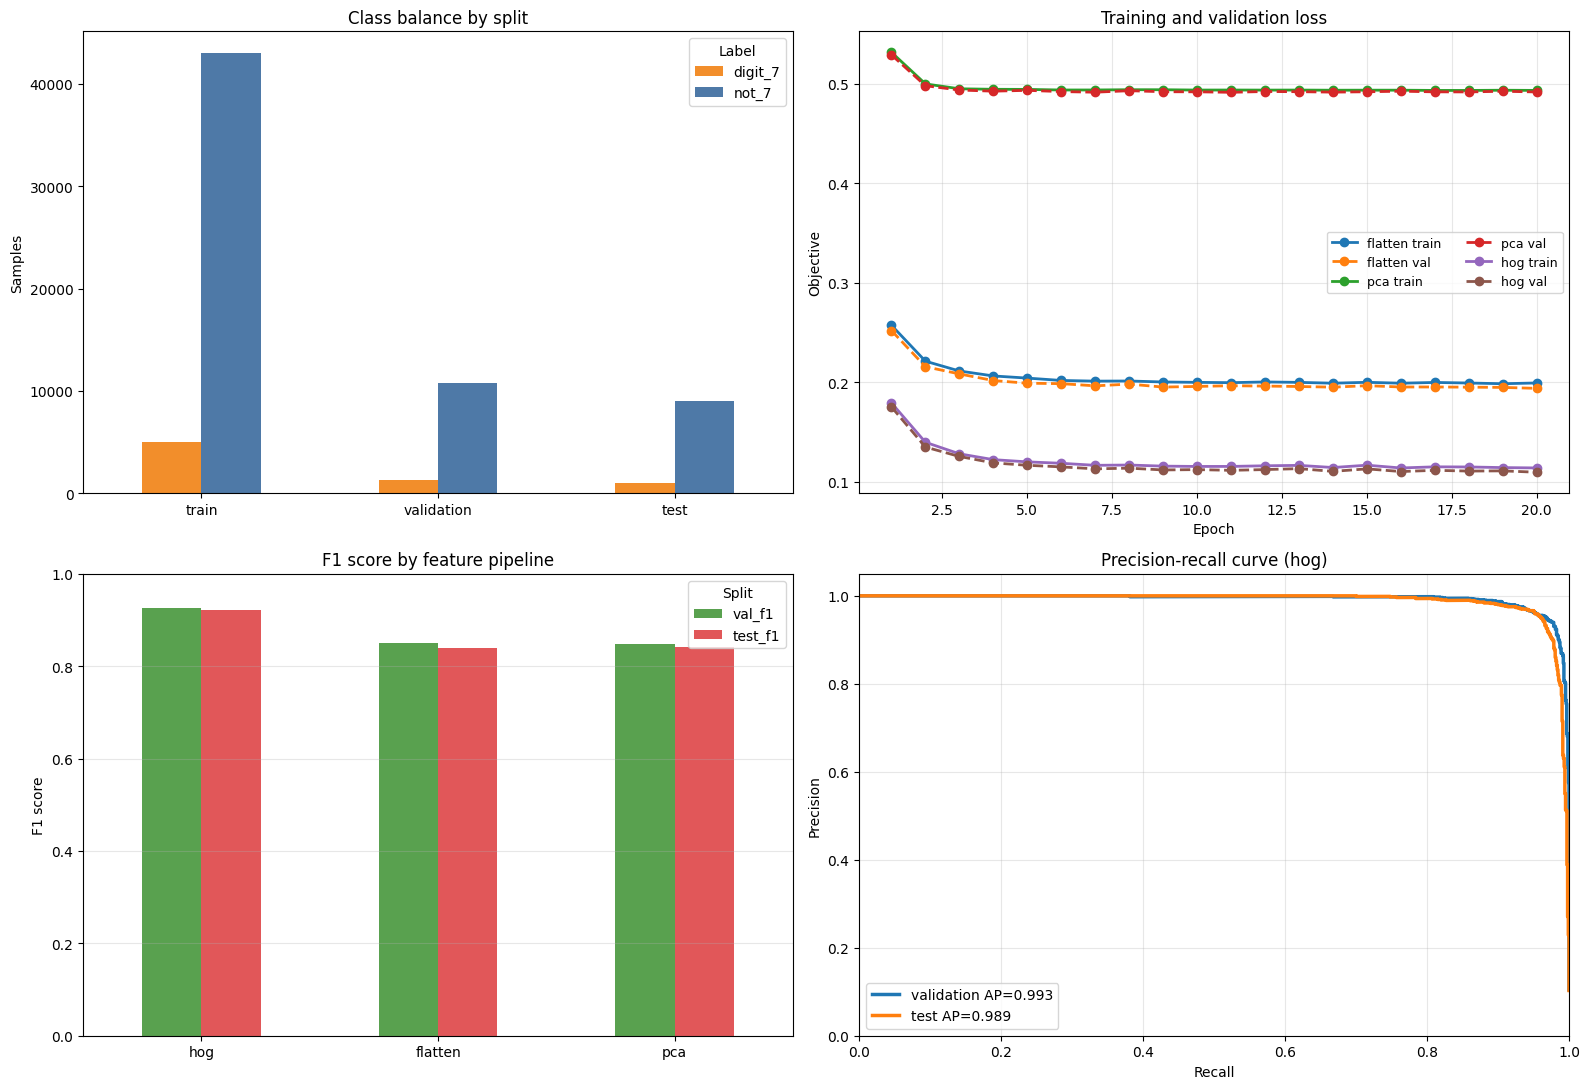

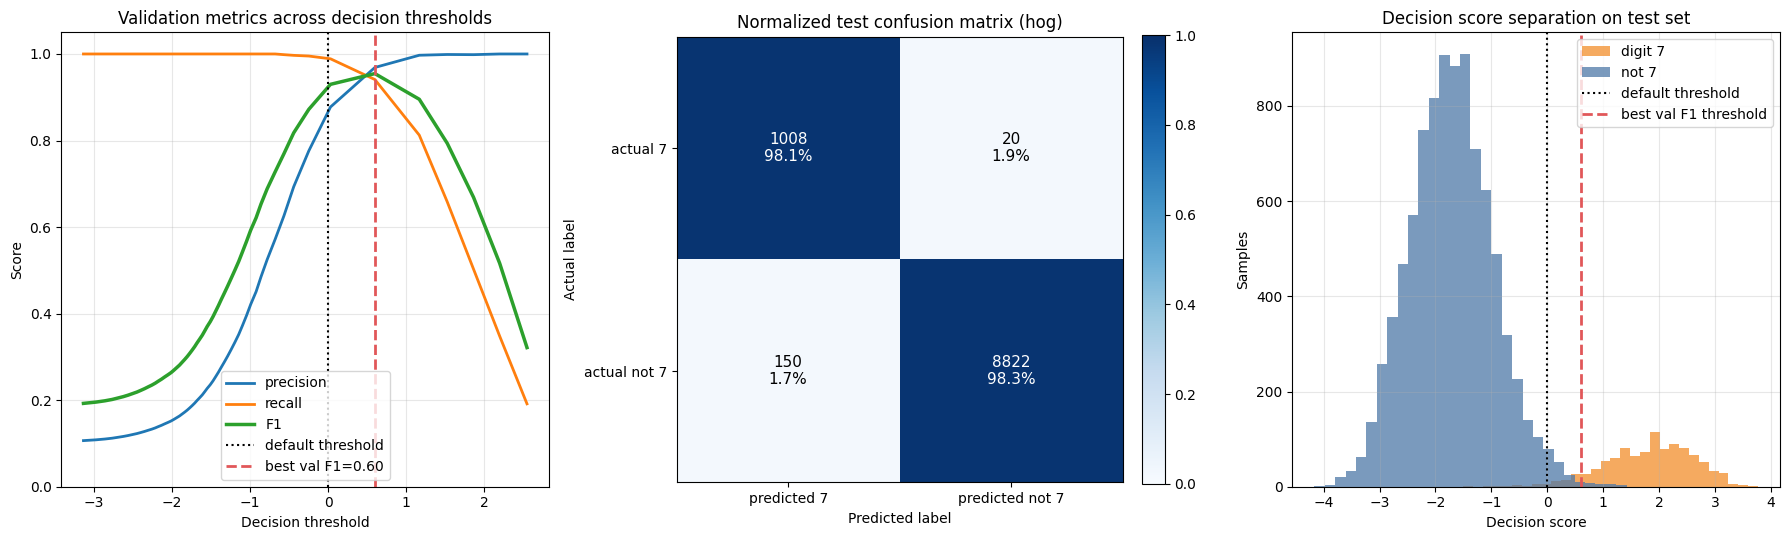

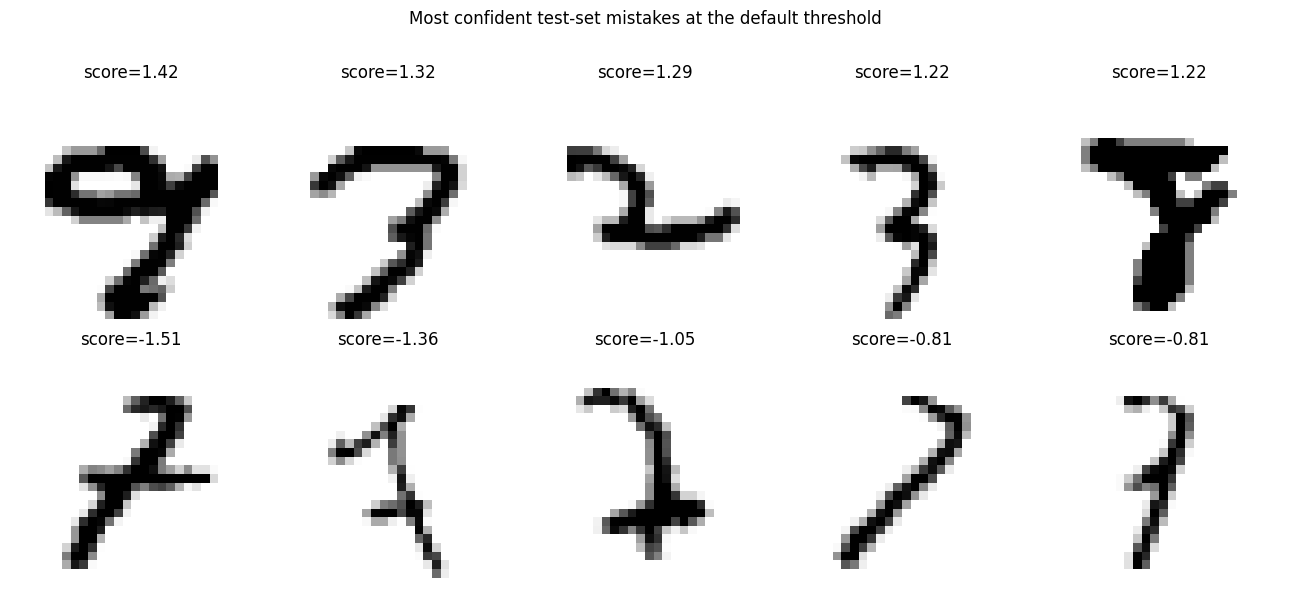

,setting,threshold,val_precision,val_recall,val_f1,test_precision,test_recall,test_f1
0,default threshold,0.0000,0.8695,0.9888,0.9253,0.8705,0.9805,0.9222
1,best validation F1 threshold,0.5981,0.9688,0.9409,0.9547,0.9734,0.9251,0.9486


In [17]:
def save_current_figure(filename):
    path = FIGURE_DIR / filename
    plt.savefig(path, dpi=180, bbox_inches="tight")
    print(f"Saved {path}")


best_mode = comparison_table.iloc[0]["feature_mode"]
best_result = experiments[best_mode]
plot_table = comparison_table.set_index("feature_mode")

best_features, _, _ = prepare_feature_set(best_mode, split_data)
best_model = best_result["model"]
val_true = split_data["y_val"]
test_true = split_data["y_test"]
val_scores = best_model.decision_function(best_features["x_val"])
test_scores = best_model.decision_function(best_features["x_test"])
test_pred = best_result["predictions"]["test"]

val_positive = (val_true == 1).astype(int)
test_positive = (test_true == 1).astype(int)

val_pr_precision, val_pr_recall, _ = precision_recall_curve(val_positive, val_scores)
test_pr_precision, test_pr_recall, _ = precision_recall_curve(test_positive, test_scores)
val_ap = average_precision_score(val_positive, val_scores)
test_ap = average_precision_score(test_positive, test_scores)

thresholds = np.unique(np.quantile(val_scores, np.linspace(0.02, 0.98, 60)))
if thresholds.size == 0:
    thresholds = np.array([0.0], dtype=np.float32)

threshold_rows = []
for threshold in thresholds:
    threshold_pred = np.where(val_scores >= threshold, 1, -1)
    threshold_report = classification_report_binary(val_true, threshold_pred)
    threshold_rows.append(
        {
            "threshold": float(threshold),
            "precision": threshold_report["precision"],
            "recall": threshold_report["recall"],
            "f1": threshold_report["f1"],
        }
    )

threshold_metrics = pd.DataFrame(threshold_rows)
default_val_report = classification_report_binary(val_true, np.where(val_scores >= 0.0, 1, -1))
best_threshold_row = threshold_metrics.loc[threshold_metrics["f1"].idxmax()]
best_threshold = float(best_threshold_row["threshold"])

tuned_val_pred = np.where(val_scores >= best_threshold, 1, -1)
tuned_test_pred = np.where(test_scores >= best_threshold, 1, -1)
tuned_val_report = classification_report_binary(val_true, tuned_val_pred)
tuned_test_report = classification_report_binary(test_true, tuned_test_pred)

threshold_summary = pd.DataFrame(
    [
        {
            "setting": "default threshold",
            "threshold": 0.0,
            "val_precision": default_val_report["precision"],
            "val_recall": default_val_report["recall"],
            "val_f1": default_val_report["f1"],
            "test_precision": best_result["reports"]["test"]["precision"],
            "test_recall": best_result["reports"]["test"]["recall"],
            "test_f1": best_result["reports"]["test"]["f1"],
        },
        {
            "setting": "best validation F1 threshold",
            "threshold": best_threshold,
            "val_precision": tuned_val_report["precision"],
            "val_recall": tuned_val_report["recall"],
            "val_f1": tuned_val_report["f1"],
            "test_precision": tuned_test_report["precision"],
            "test_recall": tuned_test_report["recall"],
            "test_f1": tuned_test_report["f1"],
        },
    ]
)

fig, axes = plt.subplots(2, 2, figsize=(16, 11))

split_summary.set_index("split")[["digit_7", "not_7"]].plot(
    kind="bar",
    ax=axes[0, 0],
    color=["#f28e2b", "#4e79a7"],
)
axes[0, 0].set_title("Class balance by split")
axes[0, 0].set_xlabel("")
axes[0, 0].set_ylabel("Samples")
axes[0, 0].tick_params(axis="x", rotation=0)
axes[0, 0].legend(title="Label")

for feature_mode, result in experiments.items():
    history = result["history"]
    axes[0, 1].plot(history["epoch"], history["train_loss"], marker="o", linewidth=2, label=f"{feature_mode} train")
    axes[0, 1].plot(history["epoch"], history["val_loss"], marker="o", linestyle="--", linewidth=2, label=f"{feature_mode} val")
axes[0, 1].set_title("Training and validation loss")
axes[0, 1].set_xlabel("Epoch")
axes[0, 1].set_ylabel("Objective")
axes[0, 1].grid(alpha=0.3)
axes[0, 1].legend(ncol=2, fontsize=9)

plot_table[["val_f1", "test_f1"]].plot(
    kind="bar",
    ax=axes[1, 0],
    color=["#59a14f", "#e15759"],
)
axes[1, 0].set_title("F1 score by feature pipeline")
axes[1, 0].set_xlabel("")
axes[1, 0].set_ylabel("F1 score")
axes[1, 0].set_ylim(0.0, 1.0)
axes[1, 0].tick_params(axis="x", rotation=0)
axes[1, 0].grid(axis="y", alpha=0.3)
axes[1, 0].legend(title="Split")

axes[1, 1].plot(val_pr_recall, val_pr_precision, linewidth=2.5, label=f"validation AP={val_ap:.3f}")
axes[1, 1].plot(test_pr_recall, test_pr_precision, linewidth=2.5, label=f"test AP={test_ap:.3f}")
axes[1, 1].set_title(f"Precision-recall curve ({best_mode})")
axes[1, 1].set_xlabel("Recall")
axes[1, 1].set_ylabel("Precision")
axes[1, 1].set_xlim(0.0, 1.0)
axes[1, 1].set_ylim(0.0, 1.05)
axes[1, 1].grid(alpha=0.3)
axes[1, 1].legend()

plt.tight_layout()
save_current_figure("svm_phase1_overview_dashboard.png")
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

axes[0].plot(threshold_metrics["threshold"], threshold_metrics["precision"], linewidth=2, label="precision")
axes[0].plot(threshold_metrics["threshold"], threshold_metrics["recall"], linewidth=2, label="recall")
axes[0].plot(threshold_metrics["threshold"], threshold_metrics["f1"], linewidth=2.5, label="F1")
axes[0].axvline(0.0, color="black", linestyle=":", linewidth=1.5, label="default threshold")
axes[0].axvline(best_threshold, color="#e15759", linestyle="--", linewidth=2, label=f"best val F1={best_threshold:.2f}")
axes[0].set_title("Validation metrics across decision thresholds")
axes[0].set_xlabel("Decision threshold")
axes[0].set_ylabel("Score")
axes[0].set_ylim(0.0, 1.05)
axes[0].grid(alpha=0.3)
axes[0].legend()

best_confusion = best_result["confusion_matrix"]
best_confusion_norm = best_confusion / best_confusion.sum(axis=1, keepdims=True)
image = axes[1].imshow(best_confusion_norm, cmap="Blues", vmin=0.0, vmax=1.0)
axes[1].set_title(f"Normalized test confusion matrix ({best_mode})")
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(["predicted 7", "predicted not 7"])
axes[1].set_yticks([0, 1])
axes[1].set_yticklabels(["actual 7", "actual not 7"])
axes[1].set_xlabel("Predicted label")
axes[1].set_ylabel("Actual label")

for (row, col), value in np.ndenumerate(best_confusion_norm):
    text_color = "white" if value > 0.5 else "black"
    axes[1].text(
        col,
        row,
        f"{best_confusion[row, col]}\n{value:.1%}",
        ha="center",
        va="center",
        color=text_color,
        fontsize=11,
    )

fig.colorbar(image, ax=axes[1], fraction=0.046, pad=0.04)

axes[2].hist(test_scores[test_true == 1], bins=30, alpha=0.75, color="#f28e2b", label="digit 7")
axes[2].hist(test_scores[test_true == -1], bins=30, alpha=0.75, color="#4e79a7", label="not 7")
axes[2].axvline(0.0, color="black", linestyle=":", linewidth=1.5, label="default threshold")
axes[2].axvline(best_threshold, color="#e15759", linestyle="--", linewidth=2, label="best val F1 threshold")
axes[2].set_title("Decision score separation on test set")
axes[2].set_xlabel("Decision score")
axes[2].set_ylabel("Samples")
axes[2].grid(alpha=0.3)
axes[2].legend()

plt.tight_layout()
save_current_figure("svm_phase1_threshold_and_scores.png")
plt.show()

fp_idx = np.flatnonzero((test_true == -1) & (test_pred == 1))
fn_idx = np.flatnonzero((test_true == 1) & (test_pred == -1))

fp_ranked = fp_idx[np.argsort(test_scores[fp_idx])[::-1]][:5]
fn_ranked = fn_idx[np.argsort(test_scores[fn_idx])][:5]

fig, axes = plt.subplots(2, 5, figsize=(13, 6))
fig.suptitle("Most confident test-set mistakes at the default threshold", y=1.02)

mistake_rows = [
    ("False positives", fp_ranked),
    ("False negatives", fn_ranked),
]

for row, (label, indices) in enumerate(mistake_rows):
    for col, ax in enumerate(axes[row]):
        ax.axis("off")
        if col < len(indices):
            idx = indices[col]
            ax.imshow(split_data["x_test"][idx], cmap="gray_r", vmin=0.0, vmax=1.0)
            ax.set_title(f"score={test_scores[idx]:.2f}")
        elif col == 2 and len(indices) == 0:
            ax.text(0.5, 0.5, "No examples", ha="center", va="center", fontsize=11)
    axes[row, 0].set_ylabel(label, fontsize=11)

plt.tight_layout()
save_current_figure("svm_phase1_mistakes.png")
plt.show()

threshold_summary.round(4)


## Result Comparison

The next cell summarizes the best-performing feature pipeline on validation F1, prints the final test metrics, and shows the test confusion matrix.


In [18]:
best_mode = comparison_table.iloc[0]["feature_mode"]
best_result = experiments[best_mode]
best_test_report = best_result["reports"]["test"]
best_history_tail = best_result["history"].tail()
best_confusion = confusion_matrix_frame(best_result["confusion_matrix"])

print(f"Best validation F1 came from: {best_mode}")
print(
    "Test metrics -> "
    f"Accuracy: {best_test_report['accuracy']:.4f}, "
    f"Precision: {best_test_report['precision']:.4f}, "
    f"Recall: {best_test_report['recall']:.4f}, "
    f"F1: {best_test_report['f1']:.4f}"
)
print("\nBest model training history (last 5 epochs):")
print(best_history_tail.to_string(index=False))
print("\nTest confusion matrix:")
print(best_confusion.to_string())


Best validation F1 came from: hog
Test metrics -> Accuracy: 0.9830, Precision: 0.8705, Recall: 0.9805, F1: 0.9222

Best model training history (last 5 epochs):
 epoch  train_loss  val_loss  val_accuracy   val_f1
    16    0.113676  0.110090      0.984583 0.930582
    17    0.114814  0.111288      0.981333 0.917221
    18    0.114677  0.110560      0.980917 0.915654
    19    0.114051  0.110756      0.986417 0.938281
    20    0.113707  0.109388      0.983333 0.925317

Test confusion matrix:
              predicted_7  predicted_not_7
actual_7             1008               20
actual_not_7          150             8822


## Interpretation Notes

The HOG feature pipeline is the strongest binary SVM representation in this notebook because it describes local stroke directions rather than relying only on raw pixel positions. This matters for handwritten digits, where shape and edge orientation are more stable than exact pixel intensity.

The default SVM threshold is very recall-oriented: it catches almost every digit 7, but it also allows more false positives. The validation-selected threshold gives a better F1 balance by raising precision while keeping recall high. For an imbalanced binary task, this threshold analysis is more informative than accuracy alone.

Recommended code-level improvements for future experiments:

- Cache HOG and PCA features so repeated tuning runs do not recompute expensive feature extraction.
- Add `balanced_accuracy` and PR-AUC to the binary metrics table for a more imbalance-aware summary.
- Run a small grid over `C`, learning rate, and threshold jointly instead of tuning only the feature pipeline and then tuning the threshold afterward.


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

def plot_confusion_matrix_and_curves(experiments):
    best_exp = max(experiments.values(), key=lambda x: x['reports']['val']['f1'])
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # 1. Confusion Matrix
    cm = best_exp['confusion_matrix']
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[0], 
                xticklabels=['7', 'Not 7'], yticklabels=['7', 'Not 7'])
    axes[0].set_title(f"Confusion Matrix (Best Model: {best_exp['feature_mode']})", fontsize=14)
    axes[0].set_xlabel('Predicted Label', fontsize=12)
    axes[0].set_ylabel('True Label', fontsize=12)
    
    # 2. Learning Curves
    history = pd.DataFrame(best_exp['history'])
    axes[1].plot(history['epoch'], history['train_loss'], label='Train Loss', marker='o')
    if 'val_loss' in history.columns:
        axes[1].plot(history['epoch'], history['val_loss'], label='Val Loss', marker='s')
    axes[1].set_title('Learning Curve (Adam + Early Stopping)', fontsize=14)
    axes[1].set_xlabel('Epoch', fontsize=12)
    axes[1].set_ylabel('Weighted Hinge Loss', fontsize=12)
    axes[1].legend()
    axes[1].grid(True, linestyle='--', alpha=0.7)
    
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / "binary_svm_visuals.png", dpi=300, bbox_inches='tight')
    plt.show()

plot_confusion_matrix_and_curves(experiments)